<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Jamboree_Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load dataset
# Replace 'your_dataset.csv' with your file path
df = pd.read_csv('/content/Jamboree_Admission.csv')

# Preview dataset
df.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# Check structure and characteristics
print("Dataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB

Summary Statistics:
       Serial No.   GRE Score  TOEFL Score  University Rating         SOP  \
count  500.000000  500.000000   500.000000         500.000000  500.000000   
mean   250.500000  316.472000   107.192000           3.114000    3.374000   
std    144.481833   11.295148     6.081868         

In [ ]:
# Drop the Serial No. column
df = df.drop(columns=['Serial No.'])


In [ ]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

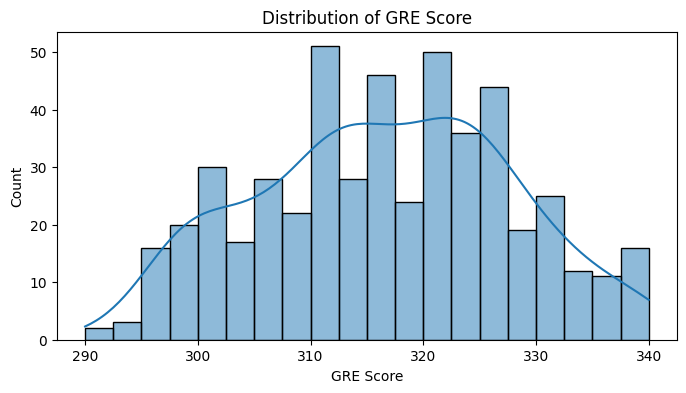

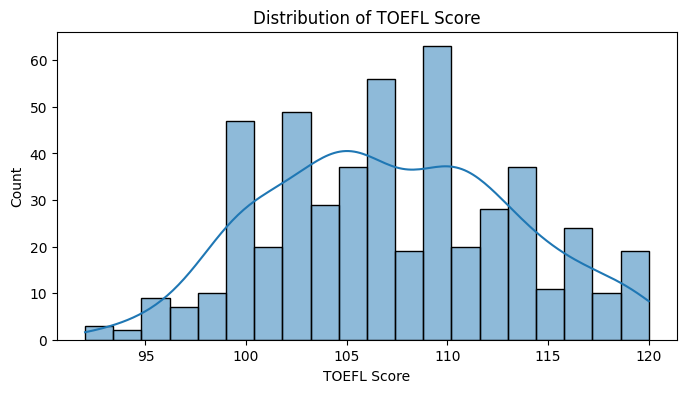

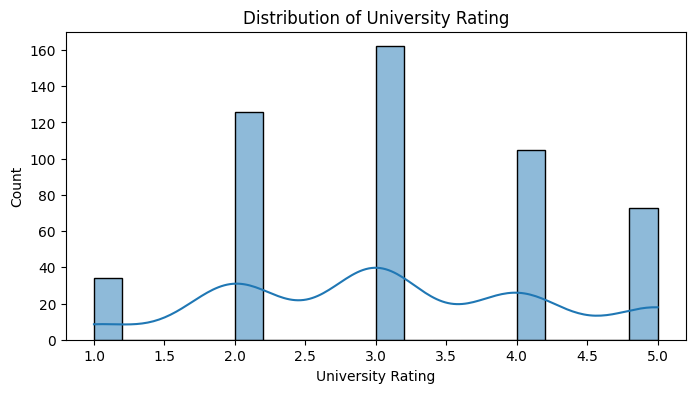

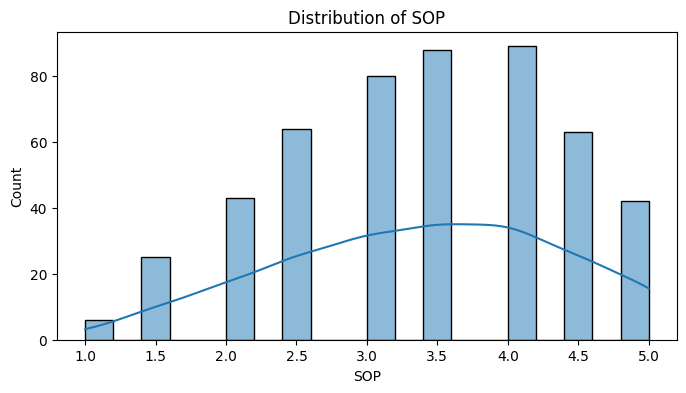

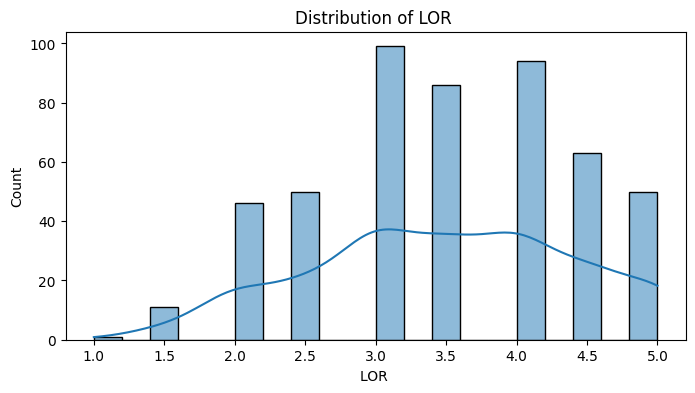

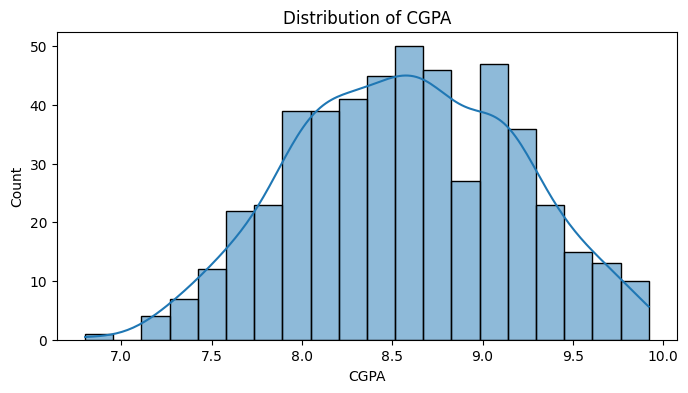

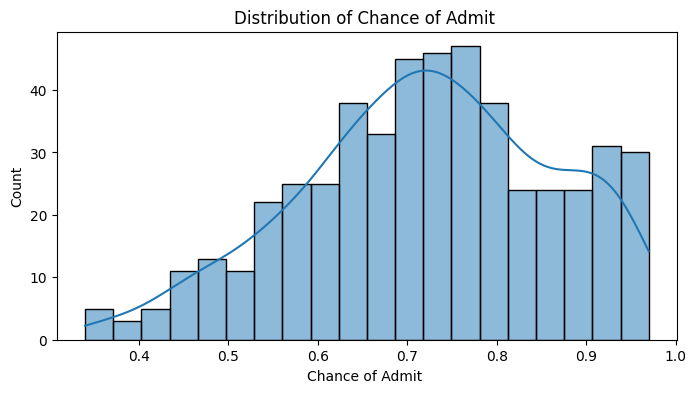

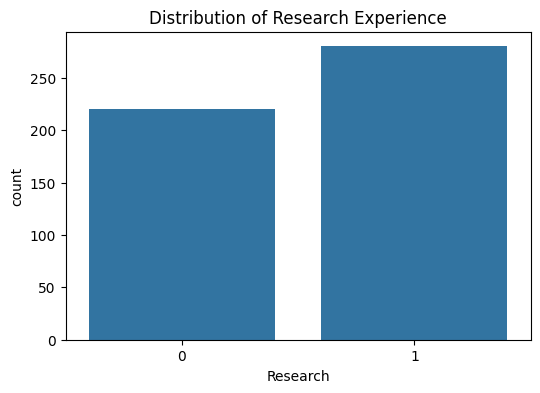

In [ ]:
# Continuous variables
continuous_vars = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Chance of Admit ']

for var in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f"Distribution of {var}")
    plt.show()

# Categorical variables
plt.figure(figsize=(6, 4))
sns.countplot(x='Research', data=df)
plt.title("Distribution of Research Experience")
plt.show()


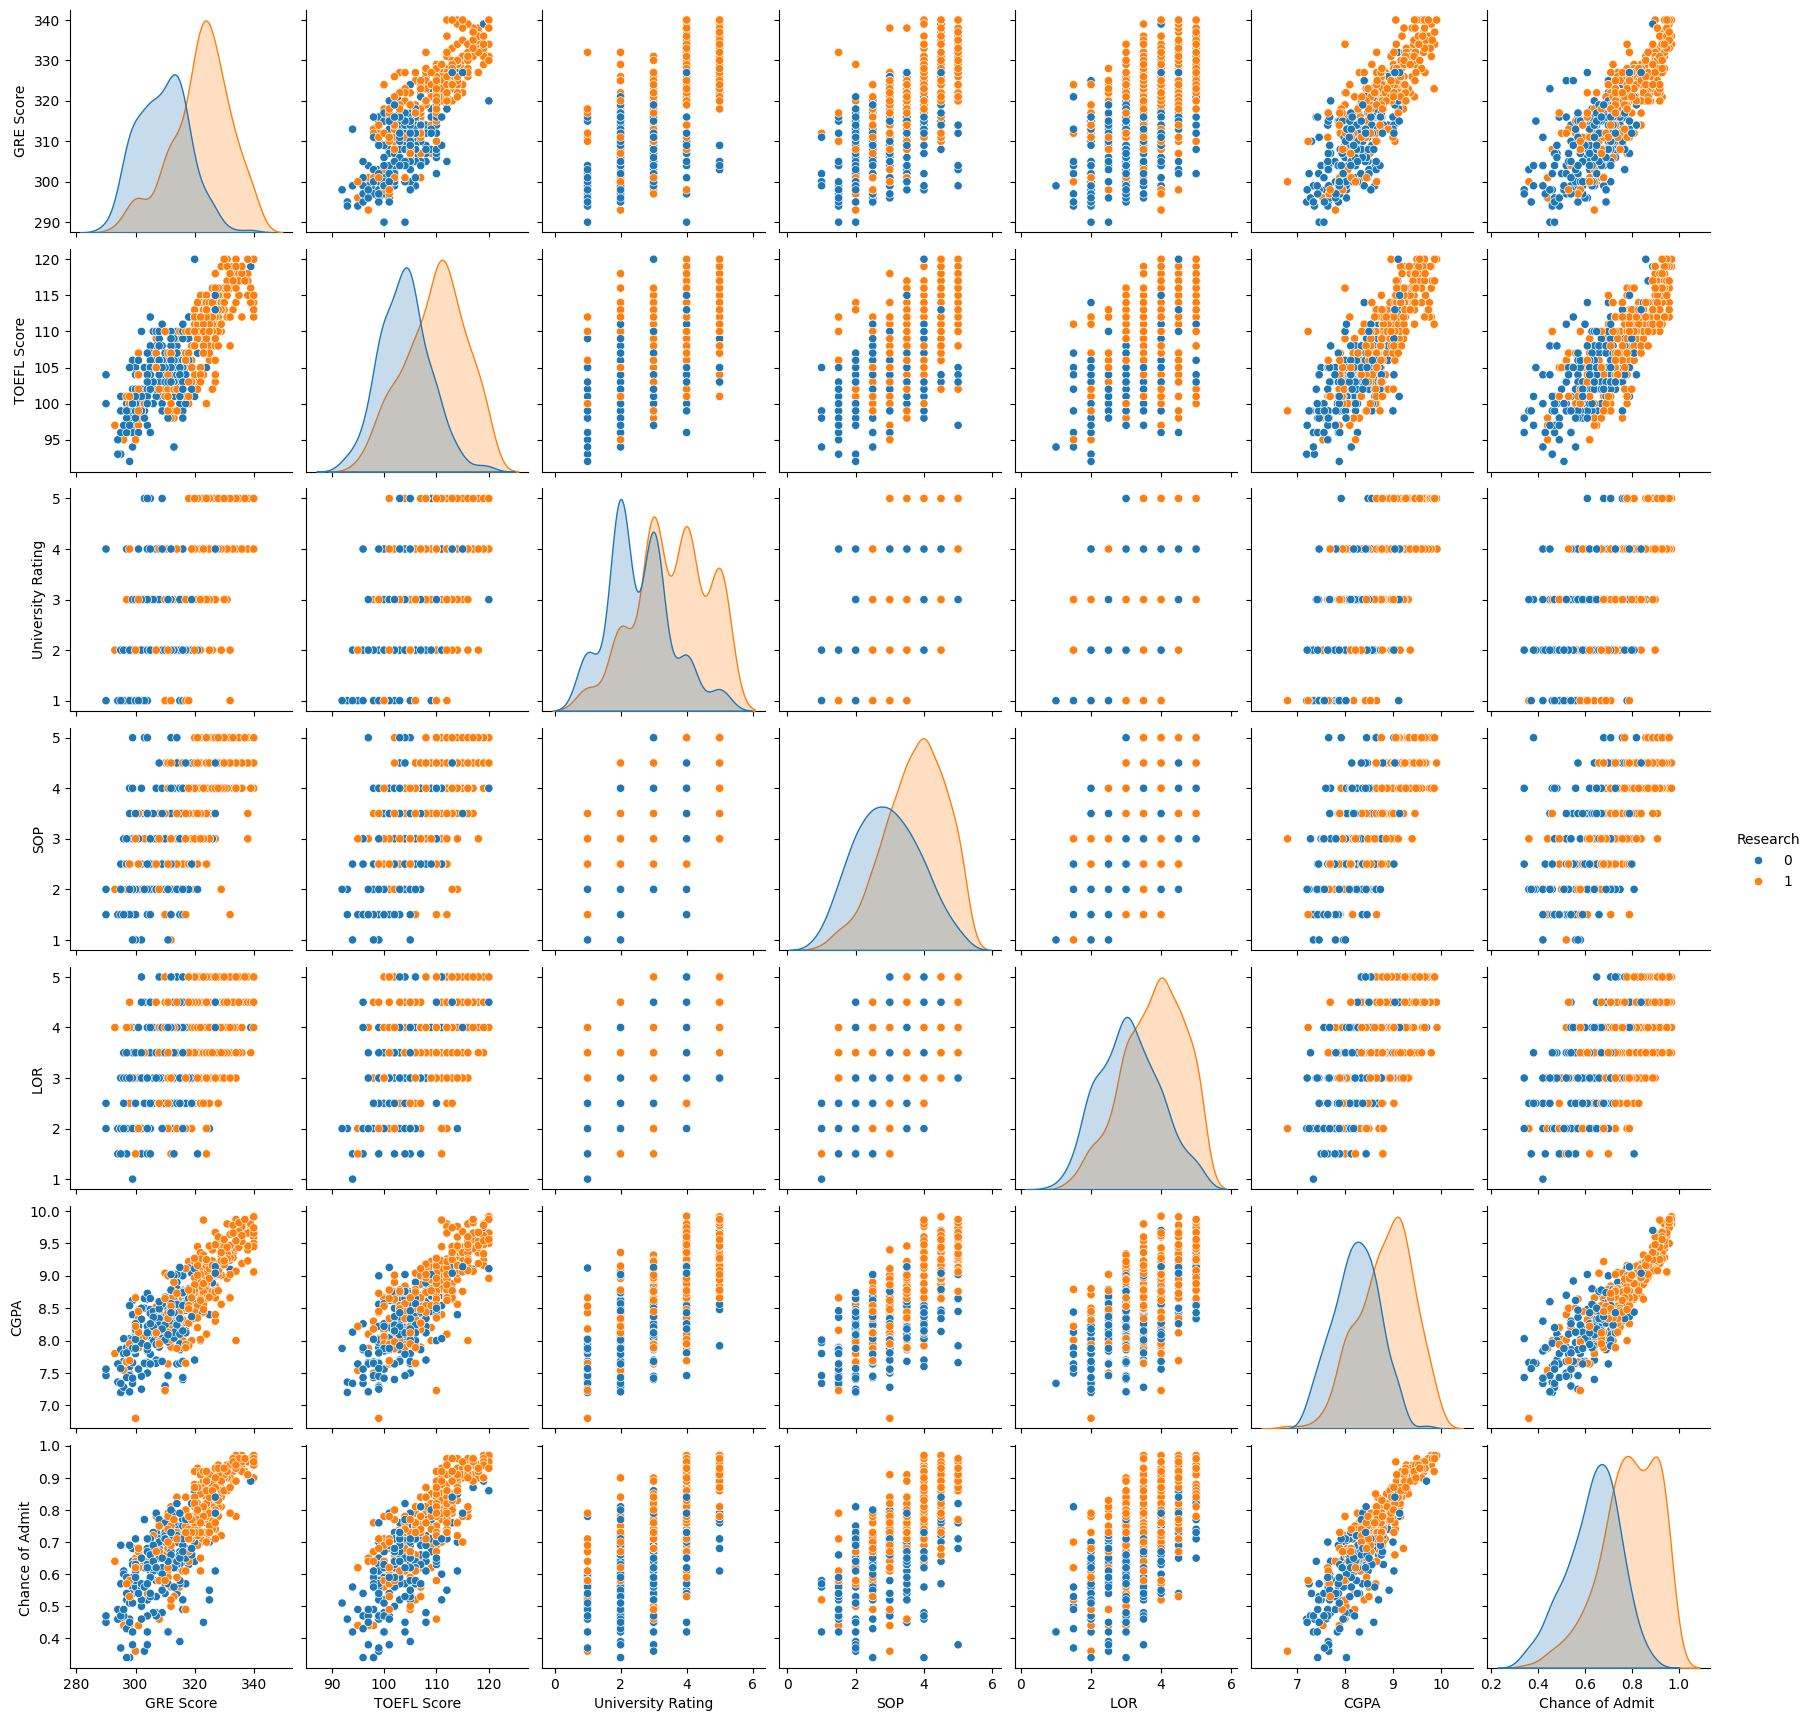

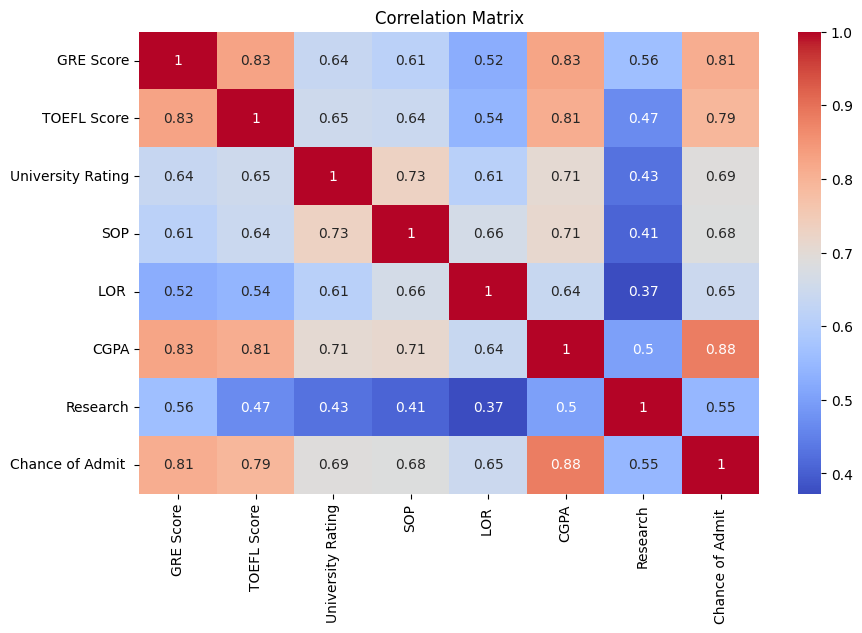

In [ ]:
# Pairplot for relationships
sns.pairplot(df, diag_kind='kde', hue='Research')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


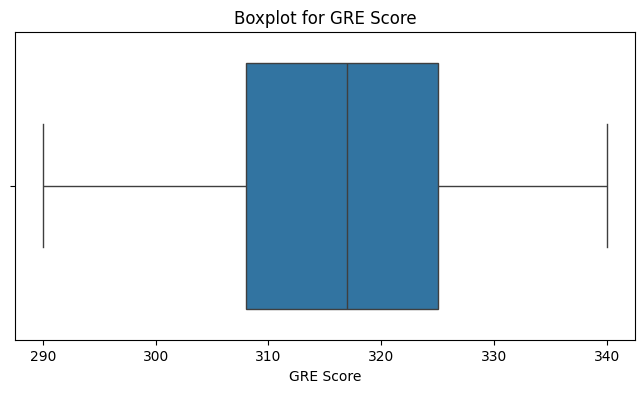

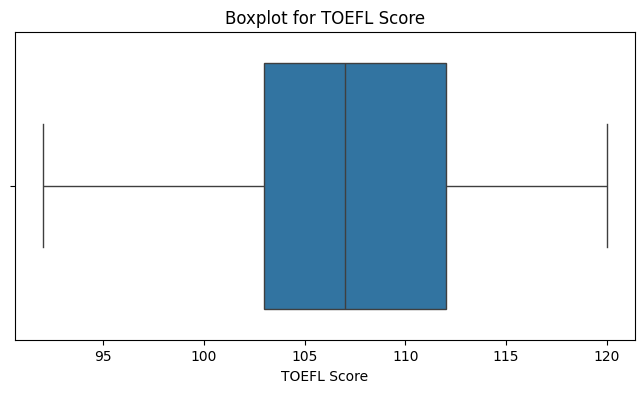

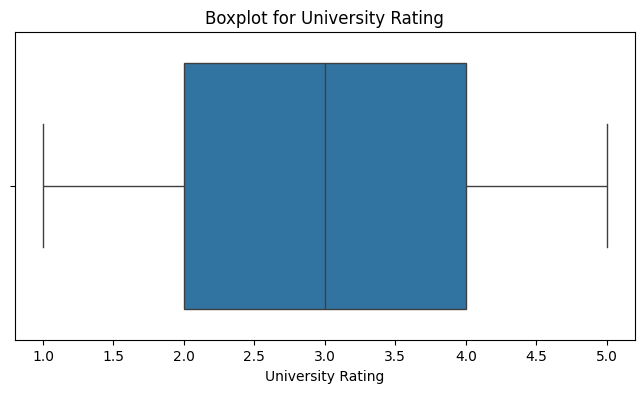

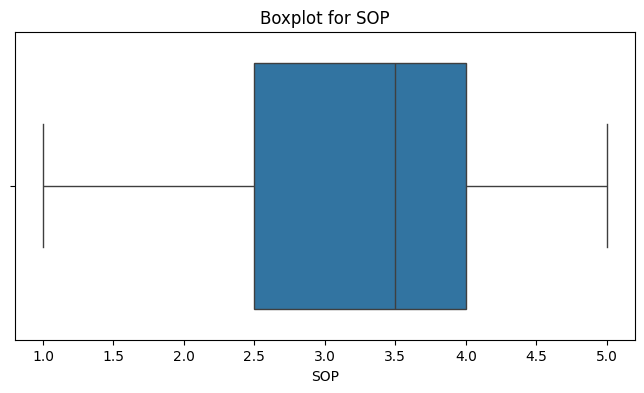

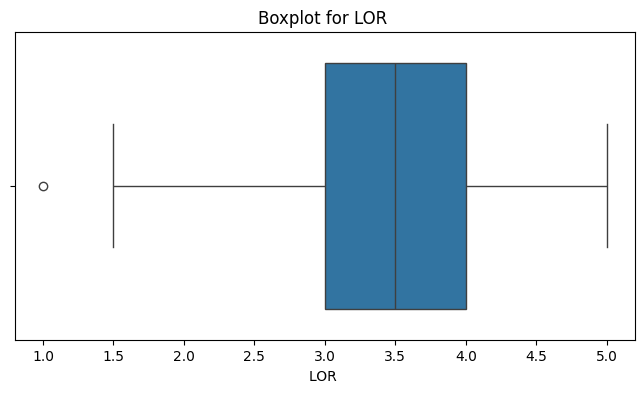

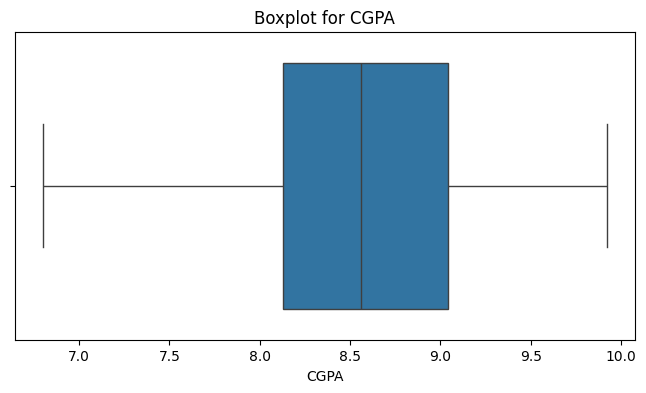

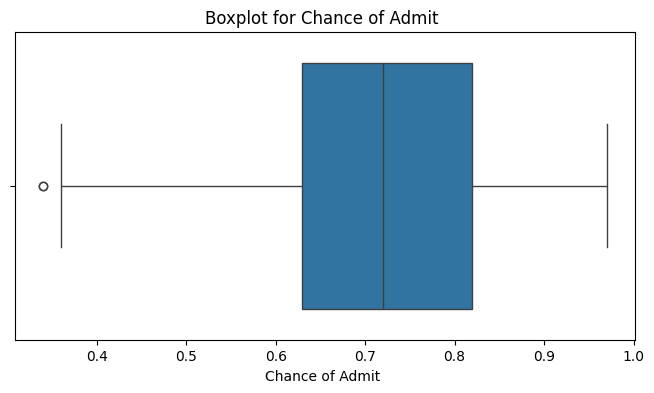

In [ ]:


# Handle missing values (if any)
df.fillna(df.median(), inplace=True)

# Check for outliers using boxplots
for var in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot for {var}")
    plt.show()

# Treat outliers (e.g., Winsorization)
from scipy.stats.mstats import winsorize

df['GRE Score'] = winsorize(df['GRE Score'], limits=[0.05, 0.05])
df['TOEFL Score'] = winsorize(df['TOEFL Score'], limits=[0.05, 0.05])


In [ ]:
# Define features and target
X = df.drop(columns=['Chance of Admit '])  # Remove extra space or correct the column name
y = df['Chance of Admit ']  # Remove extra space or correct the column name

# Add constant to predictor variables for statsmodels
X = sm.add_constant(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Fit linear regression model
model = sm.OLS(y_train, X_train).fit()

# Print summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.9
Date:                Tue, 10 Dec 2024   Prob (F-statistic):          1.86e-142
Time:                        16:40:35   Log-Likelihood:                 562.53
No. Observations:                 400   AIC:                            -1109.
Df Residuals:                     392   BIC:                            -1077.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4948      0.13

In [ ]:
# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data)


             Feature          VIF
0              const  1881.116966
1          GRE Score     4.493459
2        TOEFL Score     3.680444
3  University Rating     2.579550
4                SOP     2.793120
5               LOR      1.983194
6               CGPA     4.625514
7           Research     1.533874


In [ ]:
residuals = model.resid
print("Mean of Residuals:", np.mean(residuals))


Mean of Residuals: 1.2115308756222021e-16


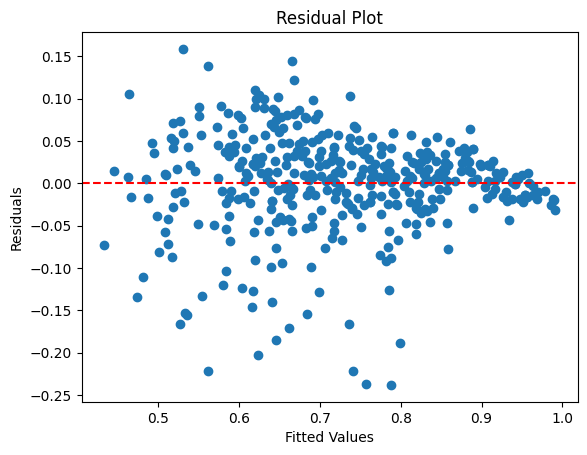

In [ ]:
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


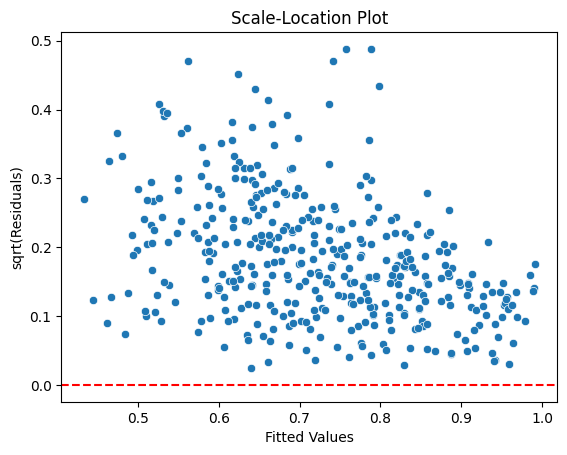

In [ ]:
sns.scatterplot(x=model.fittedvalues, y=np.sqrt(np.abs(residuals)))
plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel("sqrt(Residuals)")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()


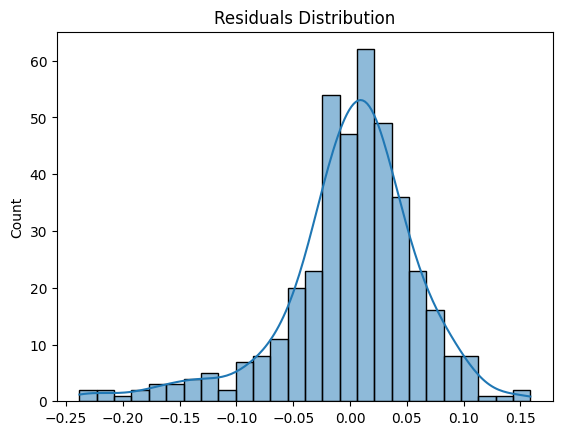

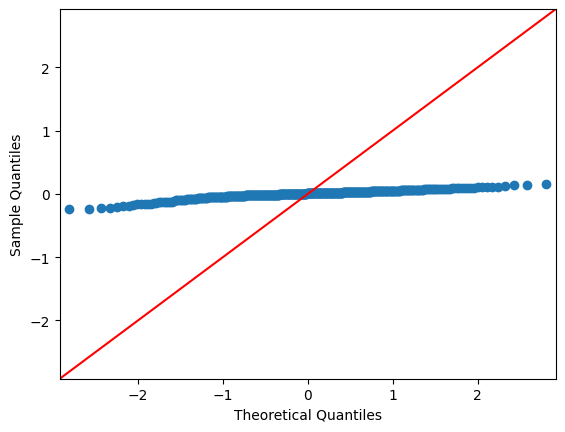

In [ ]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.show()


In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")


MAE: 0.043391642682858514
RMSE: 0.06161298508841816
R2 Score: 0.8143687075058368


10. Actionable Insights and Recommendations
Here’s where you interpret the results. Use:

Feature coefficients and significance from the regression model.
Any relationships and trends observed during EDA.
Assumptions of linear regression validated.
Example:

Features like GRE scores and GPA may have the highest impact on admission chances.
The university could focus on students with strong research backgrounds since it correlates positively.